If you aggregate
the predictions of a group of predictors (such as classifiers or regressors), you will
often get better predictions than with the best individual predictor. A group of pre‐
dictors is called an ensemble; thus, this technique is called Ensemble Learning, and an
Ensemble Learning algorithm is called an Ensemble method.


For example, you can train a group of Decision Tree classifiers, each on a different
random subset of the training set. To make predictions, you just obtain the predic‐
tions of all individual trees, then predict the class that gets the most votes 

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [80]:
from sklearn.datasets import make_moons

In [81]:
X,y = make_moons(n_samples = 400,noise = .35,random_state = 42)

In [82]:
X.shape

(400, 2)

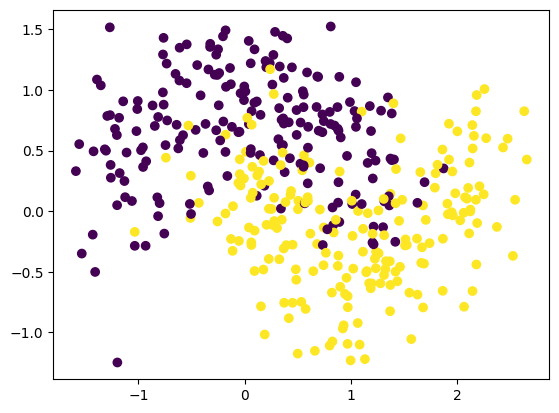

In [83]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c = y)

In [84]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42, test_size = .3)

log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC()

voting_clf = VotingClassifier(
    estimators = [('lr',log_clf),('rf',rnd_clf),('svc',svm_clf)],
    voting='hard'
)
voting_clf.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [85]:
from sklearn.metrics import accuracy_score
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test,y_pred))

LogisticRegression 0.8083333333333333
RandomForestClassifier 0.8833333333333333
SVC 0.8833333333333333
VotingClassifier 0.8833333333333333


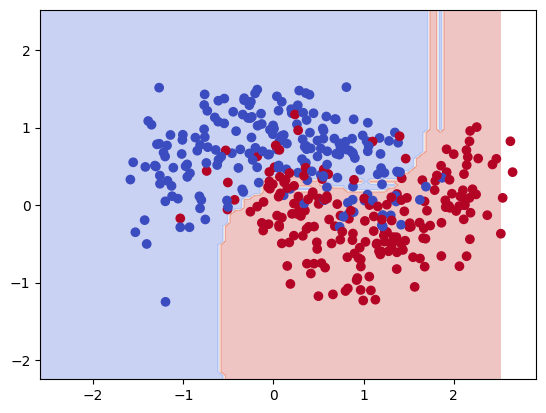

In [86]:
import numpy as np
X0_min, X0_max = X[:,0].min() - 1, X[:,1].max() + 1
X1_min, X1_max = X[:,1].min() - 1, X[:,1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(X0_min,X0_max,100),
    np.linspace(X1_min, X1_max, 100)
) 

X_new = np.c_[xx.ravel(),yy.ravel()]
y_pred = voting_clf.predict(X_new)
y_pred = y_pred.reshape(xx.shape)

plt.contourf(xx,yy,y_pred,alpha = .3, cmap ="coolwarm")
plt.scatter(X[:,0],X[:,1], c= y, cmap = 'coolwarm')
plt.show()

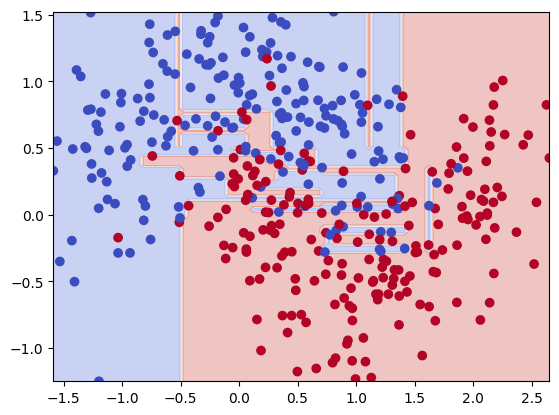

In [87]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier()
tree_clf.fit(X,y)

X0_min, X0_max = X[:,0].min(), X[:,0].max()
X1_min, X1_max = X[:,1].min(), X[:,1].max()

xx, yy = np.meshgrid(
    np.linspace(X0_min,X0_max, 100),
    np.linspace(X1_min,X1_max, 100)
)

X_new = np.c_[xx.ravel(),yy.ravel()]
y_pred = tree_clf.predict(X_new)
y_pred = y_pred.reshape(xx.shape)

plt.contourf(xx,yy,y_pred,alpha=0.3,cmap="coolwarm")
plt.scatter(X[:,0],X[:,1], c=y, cmap= "coolwarm")

Bagging 

In [88]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier 

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators = 500,
    max_samples = 100, bootstrap=True, n_jobs=-1
)

bag_clf.fit(X_train,y_train)
y_pred = bag_clf.predict(X_test)

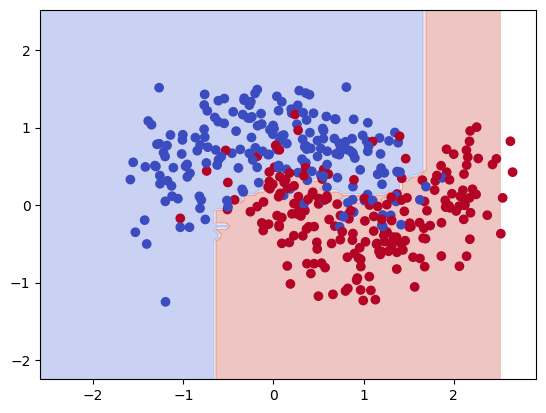

In [89]:
X0_min, X0_max = X[:,0].min() - 1, X[:,1].max() + 1
X1_min, X1_max = X[:,1].min() - 1, X[:,1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(X0_min,X0_max,100),
    np.linspace(X1_min, X1_max, 100)
) 

X_new = np.c_[xx.ravel(),yy.ravel()]
y_pred = bag_clf.predict(X_new)
y_pred = y_pred.reshape(xx.shape)

plt.contourf(xx,yy,y_pred,alpha = .3, cmap ="coolwarm")
plt.scatter(X[:,0],X[:,1], c= y, cmap = 'coolwarm')
plt.show()

Pasting

Main difference between Bagging and pasting is that Bagging allows replacements (Allowing same point multiple times int the same tree)

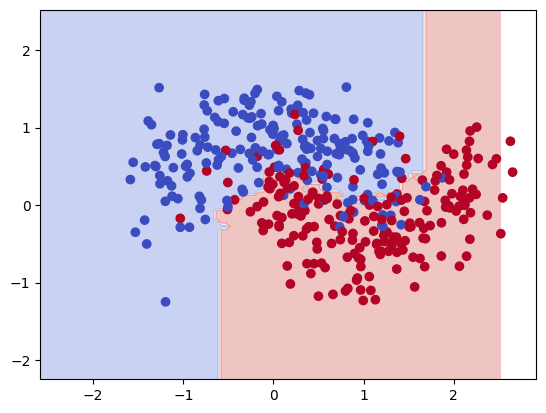

In [90]:
from sklearn.ensemble import BaggingClassifier

past_clf = BaggingClassifier(
    DecisionTreeClassifier(), bootstrap = False, n_estimators = 500, max_samples = 100, n_jobs=1
)

past_clf.fit(X_train,y_train)
y_pred = past_clf.predict(X_test)

X0_min, X0_max = X[:,0].min() - 1, X[:,1].max() + 1
X1_min, X1_max = X[:,1].min() - 1, X[:,1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(X0_min,X0_max,100),
    np.linspace(X1_min, X1_max, 100)
) 

X_new = np.c_[xx.ravel(),yy.ravel()]
y_pred = past_clf.predict(X_new)
y_pred = y_pred.reshape(xx.shape)

plt.contourf(xx,yy,y_pred,alpha = .3, cmap ="coolwarm")
plt.scatter(X[:,0],X[:,1], c= y, cmap = 'coolwarm')
plt.show()

By default a BaggingClassifier samples m
training instances with replacement (bootstrap=True), where m is the size of the
training set. This means that only about 63% of the training instances are sampled on
average for each predictor.6
 The remaining 37% of the training instances that are not
sampled are called out-of-bag (oob) instances. Note that they are not the same 37%
for all predictors.
Since a predictor never sees the oob instances during training, it can be evaluated on
these instances, without the need for a separate validation set. You can evaluate the
ensemble itself by averaging out the oob evaluations of each predictor.

In Scikit-Learn, you can set oob_score=True when creating a BaggingClassifier to
request an automatic oob evaluation after training. The following code demonstrates
this. The resulting evaluation score is available through the oob_score_ variable:

In [91]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators = 500,
    bootstrap=True, n_jobs = 1, oob_score=True
)
bag_clf.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [92]:
bag_clf.oob_score_

0.8035714285714286

In [93]:
from sklearn.metrics import accuracy_score
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.8916666666666667

In [94]:
bag_clf.oob_decision_function_

array([[0.93023256, 0.06976744],
       [0.11167513, 0.88832487],
       [0.51075269, 0.48924731],
       [0.34269663, 0.65730337],
       [0.62777778, 0.37222222],
       [0.34574468, 0.65425532],
       [0.95675676, 0.04324324],
       [1.        , 0.        ],
       [0.78443114, 0.21556886],
       [0.71122995, 0.28877005],
       [1.        , 0.        ],
       [0.56213018, 0.43786982],
       [0.00485437, 0.99514563],
       [0.        , 1.        ],
       [0.00571429, 0.99428571],
       [0.        , 1.        ],
       [0.99484536, 0.00515464],
       [1.        , 0.        ],
       [0.05464481, 0.94535519],
       [0.00526316, 0.99473684],
       [0.11458333, 0.88541667],
       [0.        , 1.        ],
       [0.2484472 , 0.7515528 ],
       [0.73369565, 0.26630435],
       [0.        , 1.        ],
       [0.97860963, 0.02139037],
       [1.        , 0.        ],
       [0.00549451, 0.99450549],
       [0.97395833, 0.02604167],
       [0.55080214, 0.44919786],
       [0.

Random Patches and Random Subspaces

The BaggingClassifier class supports sampling the features as well. This is con‐
trolled by two hyperparameters: max_features and bootstrap_features. They work
the same way as max_samples and bootstrap, but for feature sampling instead of
instance sampling. Thus, each predictor will be trained on a random subset of the
input features.

Random Forests

 Random Forest9
 is an ensemble of Decision Trees, generally
trained via the bagging method (or sometimes pasting), typically with max_samples
set to the size of the training set. Instead of building a BaggingClassifier and pass‐
ing it a DecisionTreeClassifier, you can instead use the RandomForestClassifier
class, which is more convenient and optimized for Decision Trees10 (similarly, there is
a RandomForestRegressor class for regression tasks)

In [95]:
from sklearn.ensemble import RandomForestClassifier
rnd_clf =  RandomForestClassifier(n_estimators = 500, max_leaf_nodes = 16, n_jobs=-1)
rnd_clf.fit(X_train,y_train)
y_pred = rnd_clf.predict(X_test)

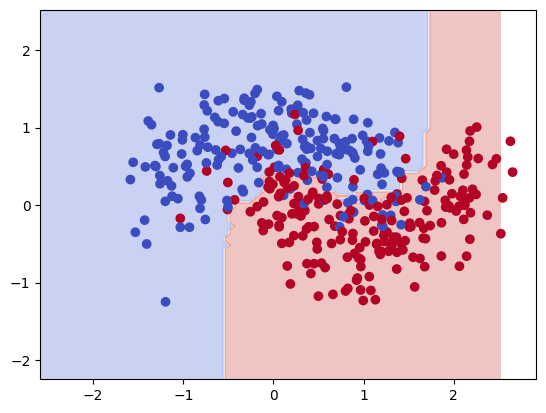

In [96]:

X0_min, X0_max = X[:,0].min() - 1, X[:,1].max() + 1
X1_min, X1_max = X[:,1].min() - 1, X[:,1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(X0_min,X0_max,100),
    np.linspace(X1_min, X1_max, 100)
) 

X_new = np.c_[xx.ravel(),yy.ravel()]
y_pred = rnd_clf.predict(X_new)
y_pred = y_pred.reshape(xx.shape)

plt.contourf(xx,yy,y_pred,alpha = .3, cmap ="coolwarm")
plt.scatter(X[:,0],X[:,1], c= y, cmap = 'coolwarm')
plt.show()

Extra-Trees

When you are growing a tree in a Random Forest, at each node only a random subset
of the features is considered for splitting (as discussed earlier). It is possible to make
trees even more random by also using random thresholds for each feature rather than
searching for the best possible thresholds (like regular Decision Trees do).


Feature Importance

Yet another great quality of Random Forests is that they make it easy to measure the
relative importance of each feature. Scikit-Learn measures a feature’s importance by
looking at how much the tree nodes that use that feature reduce impurity on average
(across all trees in the forest). More precisely, it is a weighted average, where each
node’s weight is equal to the number of training samples that are associated with it

In [97]:
from sklearn.datasets import load_iris
iris = load_iris()
rnd_clf = RandomForestClassifier(n_estimators = 500, n_jobs =-1)
rnd_clf.fit(iris["data"],iris['target'])
for name, score in zip(iris["feature_names"],rnd_clf.feature_importances_):
    print(name,score)

sepal length (cm) 0.1037440778486115
sepal width (cm) 0.025358982180439128
petal length (cm) 0.43192862005332266
petal width (cm) 0.43896831991762664


Boosting

Boosting (originally called hypothesis boosting) refers to any Ensemble method that
can combine several weak learners into a strong learner. The general idea of most
boosting methods is to train predictors sequentially, each trying to correct its prede‐
cessor

AdaBoost

One way for a new predictor to correct its predecessor is to pay a bit more attention
to the training instances that the predecessor underfitted. This results in new predictors focusing more and more on the hard cases. This is the technique used by AdaBoost.

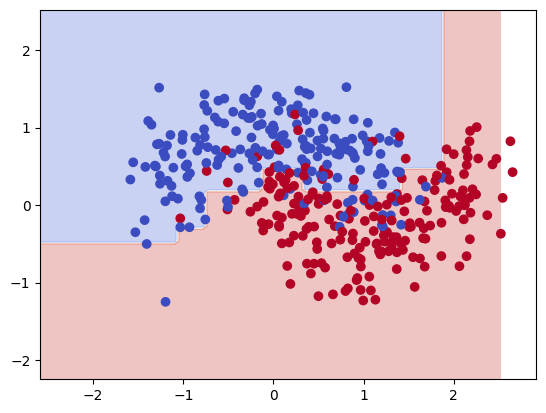

In [98]:
from sklearn.ensemble import AdaBoostClassifier
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=0.5
)
ada_clf.fit(X_train,y_train)
X0_min, X0_max = X[:,0].min() - 1, X[:,1].max() + 1
X1_min, X1_max = X[:,1].min() - 1, X[:,1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(X0_min,X0_max,100),
    np.linspace(X1_min, X1_max, 100)
) 

X_new = np.c_[xx.ravel(),yy.ravel()]
y_pred = ada_clf.predict(X_new)
y_pred = y_pred.reshape(xx.shape)

plt.contourf(xx,yy,y_pred,alpha = .3, cmap ="coolwarm")
plt.scatter(X[:,0],X[:,1], c= y, cmap = 'coolwarm')
plt.show()



Gradient Boosting

Another very popular Boosting algorithm is Gradient Boosting.
17 Just like AdaBoost,
Gradient Boosting works by sequentially adding predictors to an ensemble, each one
correcting its predecessor. However, instead of tweaking the instance weights at every
iteration like AdaBoost does, this method tries to fit the new predictor to the residual
errors made by the previous predictor

In [99]:
import numpy as np
np.random.seed(42)

m=100
X=np.random.rand(m,1)-0.5
y= 3*X[:,0]**2 +0.05*np.random.randn(m)

In [100]:
from sklearn.tree import DecisionTreeRegressor
tree_reg1 = DecisionTreeRegressor(max_depth=2)
tree_reg1.fit(X,y)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

Now train a second DecisionTreeRegressor on the residual errors made by the first
predictor:


In [101]:
y2 = y - tree_reg1.predict(X)
tree_reg2 = DecisionTreeRegressor(max_depth = 2)
tree_reg2.fit(X,y2)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [102]:
y3 = y2 - tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth = 2)
tree_reg3.fit(X,y3)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

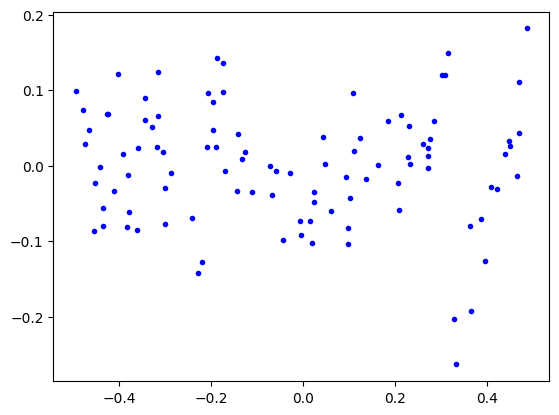

In [103]:
plt.plot(X,y3,"b.")

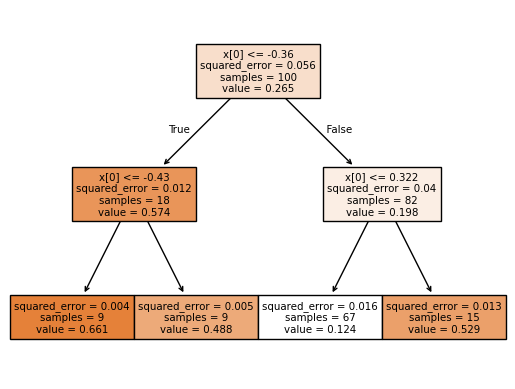

In [104]:
from sklearn.tree import plot_tree
plot_tree(tree_reg1,filled=True)
plt.show()

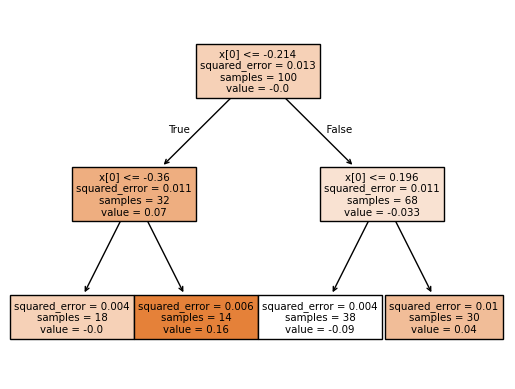

In [105]:
plot_tree(tree_reg2,filled=True)
plt.show()

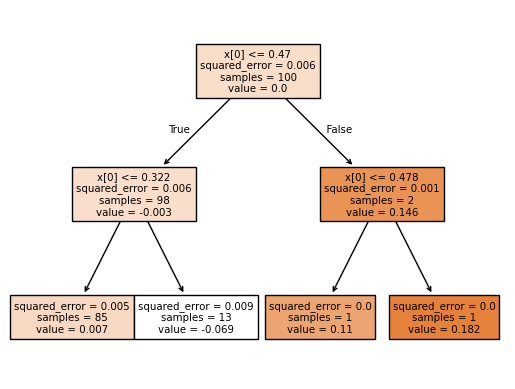

In [106]:
plot_tree(tree_reg3,filled=True)
plt.show()

Now we have an ensemble containing three trees. It can make predictions on a new
instance simply by adding up the predictions of all the trees:


In [107]:
X_new = np.linspace(X.min(),X.max(),100).reshape(-1,1)
y_pred = sum(tree.predict(X_new) for tree in (tree_reg1,tree_reg2,tree_reg3))

In [108]:
y_pred

array([0.6679558 , 0.6679558 , 0.6679558 , 0.6679558 , 0.6679558 ,
       0.6679558 , 0.6679558 , 0.49484029, 0.49484029, 0.49484029,
       0.49484029, 0.49484029, 0.49484029, 0.49484029, 0.29044761,
       0.29044761, 0.29044761, 0.29044761, 0.29044761, 0.29044761,
       0.29044761, 0.29044761, 0.29044761, 0.29044761, 0.29044761,
       0.29044761, 0.29044761, 0.29044761, 0.29044761, 0.04021166,
       0.04021166, 0.04021166, 0.04021166, 0.04021166, 0.04021166,
       0.04021166, 0.04021166, 0.04021166, 0.04021166, 0.04021166,
       0.04021166, 0.04021166, 0.04021166, 0.04021166, 0.04021166,
       0.04021166, 0.04021166, 0.04021166, 0.04021166, 0.04021166,
       0.04021166, 0.04021166, 0.04021166, 0.04021166, 0.04021166,
       0.04021166, 0.04021166, 0.04021166, 0.04021166, 0.04021166,
       0.04021166, 0.04021166, 0.04021166, 0.04021166, 0.04021166,
       0.04021166, 0.04021166, 0.04021166, 0.04021166, 0.04021166,
       0.17052257, 0.17052257, 0.17052257, 0.17052257, 0.17052

In [109]:
X.shape

(100, 1)

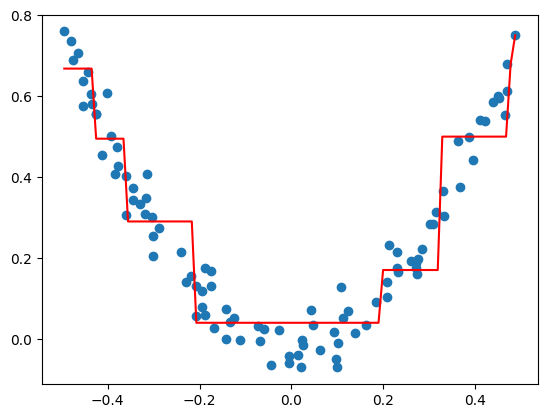

In [110]:
plt.plot(X_new,y_pred,"r-")
plt.scatter(X,y)

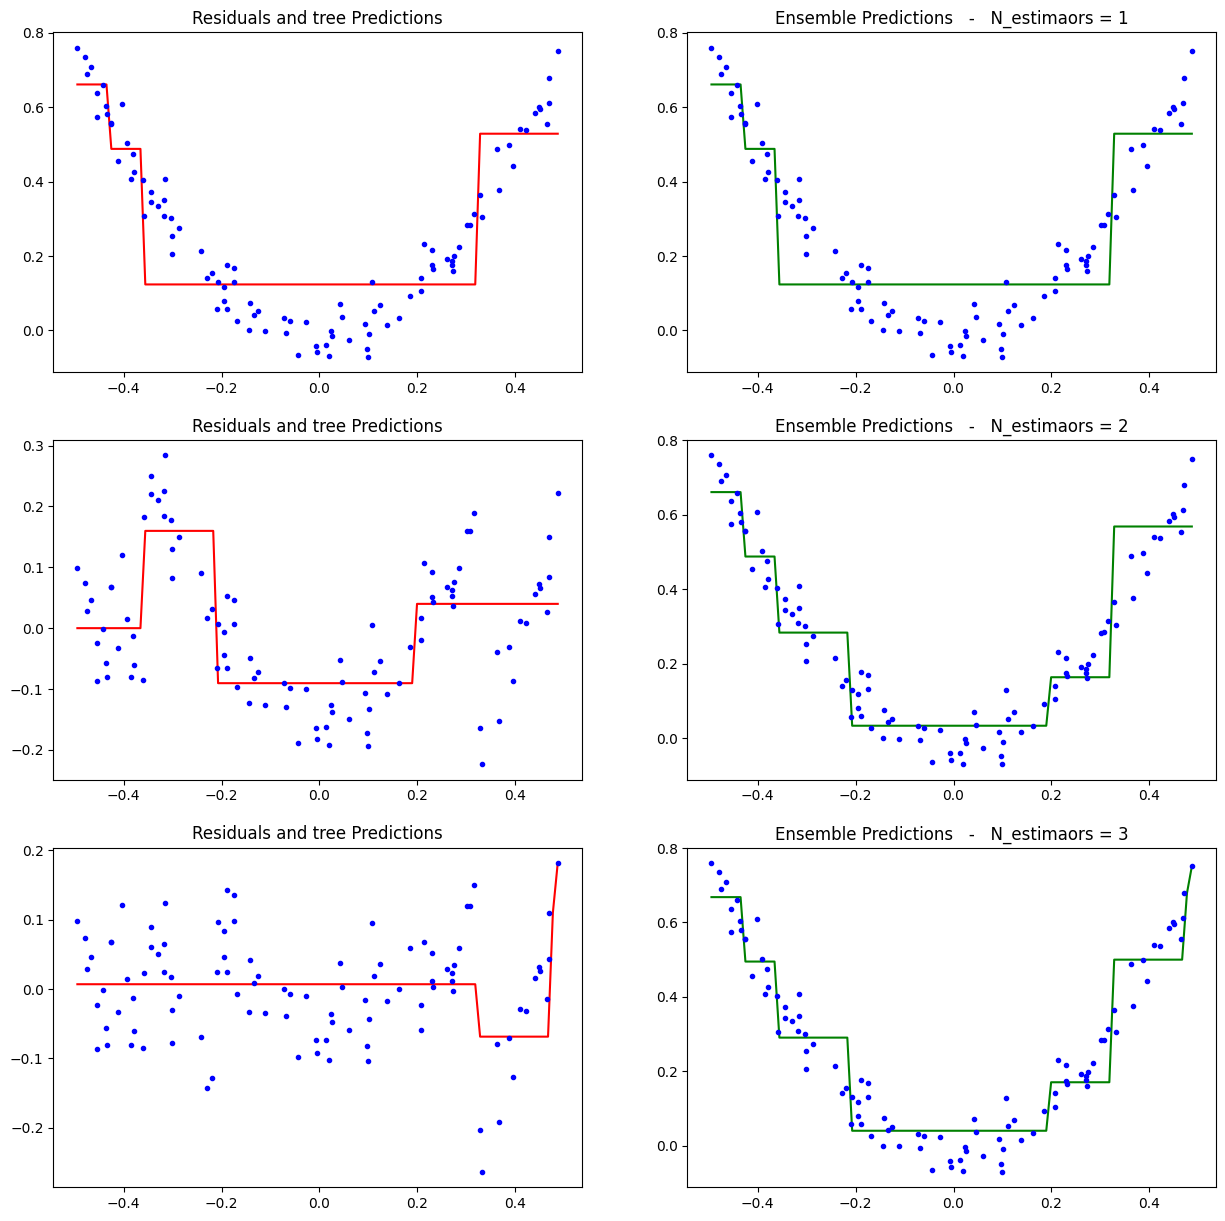

In [121]:
j = 1
tree_reg = DecisionTreeRegressor(max_depth = 2)
y2 = y
plt.figure(figsize=(15,15))
for i in range (3):
    tree_reg.fit(X,y2)
    y2_pred = tree_reg.predict(X_new)

    plt.subplot(3,2,j)
    plt.plot(X_new,y2_pred,'r-')
    plt.plot(X,y2,'b.')
    plt.title("Residuals and tree Predictions")

    y2 =  y2 - tree_reg.predict(X)



    from sklearn.ensemble import GradientBoostingRegressor
    gbrt= GradientBoostingRegressor(max_depth=2,n_estimators=i+1,learning_rate=1)
    gbrt.fit(X,y)
    y_pred = gbrt.predict(X_new)
    plt.subplot(3,2,j+1)
    plt.plot(X_new,y_pred,'g-')
    plt.plot(X,y,'b.')
    plt.title(f"Ensemble Predictions   -   N_estimaors = {i+1}")
    j = j +2
plt.show()